In [21]:
!pip install openpyxl
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 7.9 MB/s  0:00:00 eta 0:00:01


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Creating the neural network

In [118]:
# Create model class - inherits nn.Module
class StudentPerformanceModel(nn.Module):
    # input layer (4 features of flower: sepal len, sepal width, petal len, petal wid) ->
    # -> hidden layer1 (neurons) -> H2 (n) ->
    # output (3 classes of iris flowers)
    def __init__(self, inputFeatures=8, h1=10, h2=12, outputFeatures=2):
        super().__init__() # instantiate nn.Module
        self.fc1 = nn.Linear(inputFeatures, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, outputFeatures)

    # function that moves everything forward
    def forward(self, x):
        x = F.relu(self.fc1(x)) #do something, if output is less than 0, otherwise, use output
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x
    
model = StudentPerformanceModel()

# EDA

In [15]:
df = pd.read_excel("data/Student-Employability-Datasets.xlsx")
df

,Name of Student,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating,CLASS
0,Student 1,4,5,4,5,5,5,5,5,Employable
1,Student 2,4,4,4,4,4,4,3,5,Employable
2,Student 3,4,3,3,3,3,3,2,5,LessEmployable
3,Student 4,3,3,3,2,3,3,3,5,LessEmployable
4,Student 5,4,4,3,3,4,4,3,5,Employable
...,...,...,...,...,...,...,...,...,...,...
2977,Student 2996,4,3,3,3,3,3,2,5,Employable
2978,Student 2997,3,4,4,4,4,4,4,5,Employable
2979,Student 2998,4,5,4,5,4,4,4,5,Employable
2980,Student 2999,4,4,4,3,4,4,3,5,LessEmployable


In [16]:
df.describe()

,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating
count,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000
mean,4.246814,3.884641,3.972166,3.962777,3.910798,3.813883,3.525486,4.610664
std,0.678501,0.757013,0.744135,0.781982,0.807602,0.739390,0.743881,0.692845
min,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000
25%,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000
75%,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000,4.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [18]:
df['CLASS'].unique()

array(['Employable', 'LessEmployable'], dtype=object)

In [19]:
df['CLASS'] = df['CLASS'].replace('Employable', 0.0)
df['CLASS'] = df['CLASS'].replace('LessEmployable', 1.0)
df

/var/folders/v9/gwff8t8s5dd558r0kx786ctr0000gn/T/ipykernel_2443/2164124956.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['CLASS'] = df['CLASS'].replace('LessEmployable', 1.0)


,Name of Student,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating,CLASS
0,Student 1,4,5,4,5,5,5,5,5,0.0
1,Student 2,4,4,4,4,4,4,3,5,0.0
2,Student 3,4,3,3,3,3,3,2,5,1.0
3,Student 4,3,3,3,2,3,3,3,5,1.0
4,Student 5,4,4,3,3,4,4,3,5,0.0
...,...,...,...,...,...,...,...,...,...,...
2977,Student 2996,4,3,3,3,3,3,2,5,0.0
2978,Student 2997,3,4,4,4,4,4,4,5,0.0
2979,Student 2998,4,5,4,5,4,4,4,5,0.0
2980,Student 2999,4,4,4,3,4,4,3,5,1.0


In [ ]:
# train, test, split [set x,y]
X = df.drop('CLASS', axis=1)
y = df['CLASS']

X

,Name of Student,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating
0,Student 1,4,5,4,5,5,5,5,5
1,Student 2,4,4,4,4,4,4,3,5
2,Student 3,4,3,3,3,3,3,2,5
3,Student 4,3,3,3,2,3,3,3,5
4,Student 5,4,4,3,3,4,4,3,5
...,...,...,...,...,...,...,...,...,...
2977,Student 2996,4,3,3,3,3,3,2,5
2978,Student 2997,3,4,4,4,4,4,4,5
2979,Student 2998,4,5,4,5,4,4,4,5
2980,Student 2999,4,4,4,3,4,4,3,5


In [25]:
X = X.drop(columns='Name of Student') 

# convert to numpy array
X = X.values
y = y.values

# Model

In [152]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=32)

# convert to tensor
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

# convert to tensor - since 0, 1
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

# set criterion of model to measure error; how far off the predictions are from the data
criterion = nn.CrossEntropyLoss()
# Choose optimizer, lr = learning rate (if error doesnt go down after a bunch of epochs, lower learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [153]:
# train the model
# epoch = 1 run through all training data in the network
epochs = 6000
# keep track of loss to see if the model is learning
losses = []
for i in range(epochs):
    # Go forward and get prediction
    y_pred = model.forward(X_train) # get predicted results
    # Measure loss/error, going to be high at first
    loss = criterion(y_pred, y_train)
    # Keep track of our losses
    losses.append(loss.detach().numpy())
    # print every 10 epochs to see what is happening
    if i % 1000 == 0:
        print(f"Epoch: {i} and loss: {loss}")
    # do some back propagation, take error rate of forward prop,
    # then feed it back via nn to fine tune the weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch: 0 and loss: 0.30279093980789185
Epoch: 1000 and loss: 0.30266934633255005
Epoch: 2000 and loss: 0.30087125301361084
Epoch: 3000 and loss: 0.29941824078559875
Epoch: 4000 and loss: 0.298155814409256
Epoch: 5000 and loss: 0.2975158989429474


Text(0.5, 0, 'epochs')

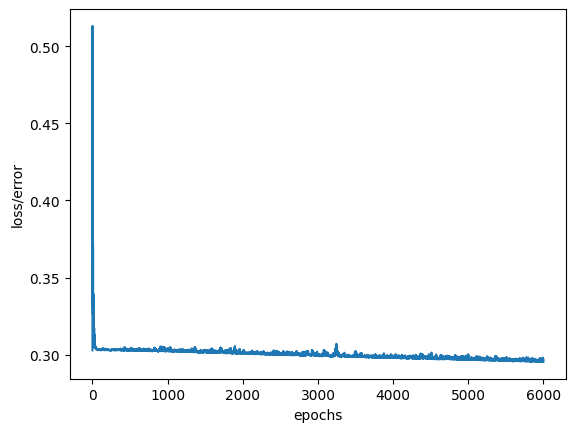

In [154]:
# graph it out
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel("epochs")

In [155]:
# evaluate model on test data set
with torch.no_grad(): # turn off back prop
    y_eval = model.forward(X_test)
    loss = criterion(y_eval, y_test)

correct = 0
incorrect = 0
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)

        if y_test[i] == 0:
            x = "Employable"
        else:
            x = 'LessEmployable'

        print(f"{i+1}.) {str(y_val)} \t {x} \t {y_val.argmax().item()}")

        # tell us type of flower networks thinks it is
        # print(f"{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}")

        # correct or not
        if y_val.argmax().item() == y_test[i]:
            correct += 1
        else:
            incorrect += 1


print(f"Number of corrects: {correct}")
print(f"Number of incorrect: {incorrect}")
print(f"Accuracy: {correct / (correct+incorrect)}")

1.) tensor([ 1.2161, -0.4386]) 	 Employable 	 0
2.) tensor([-7.2984,  7.5732]) 	 LessEmployable 	 1
3.) tensor([ 1.7934, -1.4877]) 	 Employable 	 0
4.) tensor([-0.8114,  1.0896]) 	 Employable 	 1
5.) tensor([1.0476, 0.0472]) 	 LessEmployable 	 0
6.) tensor([ 1.3482, -0.8229]) 	 Employable 	 0
7.) tensor([0.2814, 0.7523]) 	 Employable 	 1
8.) tensor([-1.5621,  2.2094]) 	 LessEmployable 	 1
9.) tensor([ 5.6352, -4.1936]) 	 Employable 	 0
10.) tensor([ 0.8869, -0.4998]) 	 LessEmployable 	 0
11.) tensor([ 4.6337, -4.0806]) 	 Employable 	 0
12.) tensor([ 1.8717, -1.6862]) 	 Employable 	 0
13.) tensor([-1.5293,  1.5474]) 	 LessEmployable 	 1
14.) tensor([-0.8114,  1.0896]) 	 Employable 	 1
15.) tensor([0.0709, 0.4894]) 	 LessEmployable 	 1
16.) tensor([ 3.5313, -1.8799]) 	 Employable 	 0
17.) tensor([0.1807, 0.8266]) 	 Employable 	 1
18.) tensor([-4.9323,  4.7982]) 	 LessEmployable 	 1
19.) tensor([ 11.1716, -10.3079]) 	 Employable 	 0
20.) tensor([-1.8588,  2.3963]) 	 LessEmployable 	 1
21.